# How Close Can I Get to Vegas Lines with Free Data?

**Notebook Overview**  

 In this notebook, we:
 1. Fetch and prepare Ja Morant's performance logs from the NBA API.
 2. Merge with betting data (spreads) from a Kaggle dataset.
 3. Engineer features (e.g., rest days, rolling averages).
 4. Train and compare multiple models (Linear, Ridge, Lasso, RF, XGBoost, LightGBM).
 5. Perform hyperparameter tuning (Ridge, RF) to improve predictions.
 6. Evaluate results and plot outcomes.

## 1. Imports and Setup
 Import libraries for data retrieval, manipulation, visualization, and model training/evaluation.


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import string
import requests
import json
from datetime import datetime

# NBA API Imports
from nba_api.stats.endpoints import playergamelog
from nba_api.stats.library.parameters import SeasonAll

# Modeling and Evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.feature_selection import f_regression

# Visualization / Display
from itables import show
from summarytools import dfSummary

## 2. Fetch Ja Morant Game Logs
Retrieve all available game logs for Ja Morant from the NBA API.

In [45]:
ja_morant_stats = playergamelog.PlayerGameLog(player_id='201942', season=SeasonAll.all)
player_stats = ja_morant_stats.get_data_frames()[0]

## 3. Feature Engineering

We will:
- Identify home/away and interdivisional games.
- Calculate rest days between games and categorize them.
- Create per-minute stats and rolling averages (3, 7, 15 games).

In [46]:
nba_divisions = {
    "Eastern Conference": {
        "ATLANTIC": ["BOS", "BKN", "NYK", "PHI", "TOR"],
        "CENTRAL": ["CHI", "CLE", "DET", "IND", "MIL"],
        "SOUTHEAST": ["ATL", "CHA", "MIA", "ORL", "WAS"]
    },
    "Western Conference": {
        "NORTHWEST": ["DEN", "MIN", "OKC", "POR", "UTA"],
        "PACIFIC": ["GSW", "LAC", "LAL", "PHX", "SAC"],
        "SOUTHWEST": ["DAL", "HOU", "MEM", "NOP", "SAS"]
    }
}

def extract_teams(matchup):
    """ Extracts the home and away teams from a matchup string """
    if " @ " in matchup:
        return matchup.split(" @ ")
    elif " vs. " in matchup:
        return matchup.split(" vs. ")
    return None, None

def find_division(team_name):
    """ Finds the division of a team given the team's abbreviation """
    for conference, divisions in nba_divisions.items():
        for division, teams in divisions.items():
            if team_name in teams:
                return division
    return None

def is_interdivisional(player_team, opponent):
    """ Check if a game is interdivisional """
    player_division = find_division(player_team)
    opponent_division = find_division(opponent)
    if player_division and opponent_division and player_division != opponent_division:
        for conference, divisions in nba_divisions.items():
            if player_team in sum(divisions.values(), []) and opponent in sum(divisions.values(), []):
                return 1
    return 0

def classify_rest_days(days):
    """ Categorized the number of rest days into 3 categories """
    if days < 2:
        return 'Less than 2 days'
    elif 2 <= days <= 3:
        return '2-3 days'
    else:
        return 'More than 3 days'

def add_home_away_teams(dataframe):
    """ Assign which team is the home team and which team is the away team """
    def split_matchup(row):
        if "vs." in row['MATCHUP']:
            return pd.Series([row['Player_Team'], row['Opponent']], index=['Home_Team', 'Away_Team'])
        elif "@" in row['MATCHUP']:
            return pd.Series([row['Opponent'], row['Player_Team']], index=['Home_Team', 'Away_Team'])
        return pd.Series([None, None], index=['Home_Team', 'Away_Team'])
    dataframe[['Home_Team', 'Away_Team']] = dataframe.apply(split_matchup, axis=1)
    return dataframe

# List of columns for which we will create per-minute stats
columns_to_per_minute = [
    'FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS'
]

In [47]:
# Convert GAME_DATE to datetime
player_stats['GAME_DATE'] = pd.to_datetime(player_stats['GAME_DATE'])

# Extract player team and opponent from MATCHUP
player_stats['Player_Team'], player_stats['Opponent'] = zip(*player_stats['MATCHUP'].apply(extract_teams))

# Add home court advantage column
player_stats['Home_Court_Advantage'] = player_stats['MATCHUP'].apply(lambda x: 1 if 'vs.' in x else 0)

# Add interdivisional game column
player_stats['Interdivisional_Game'] = player_stats.apply(lambda x: is_interdivisional(x['Player_Team'], x['Opponent']), axis=1)

# Sort by date for rolling calculations
player_stats = player_stats.sort_values(by=['SEASON_ID', 'Player_ID', 'GAME_DATE']).reset_index(drop=True)

# Identify home and away teams
player_stats = add_home_away_teams(player_stats)

# Calculate rest days
player_stats['Rest_Days'] = player_stats.groupby(['SEASON_ID', 'Player_ID'])['GAME_DATE'].diff().dt.days
player_stats['Rest_Days'] = player_stats['Rest_Days'].fillna(0).astype(int)
player_stats['Rest_Category'] = player_stats['Rest_Days'].apply(classify_rest_days)

# One-hot encode rest categories
rest_category_dummies = pd.get_dummies(player_stats['Rest_Category'])
rest_category_dummies.columns = ['Rest_Category_' + str(col) for col in rest_category_dummies.columns]
player_stats = pd.concat([player_stats, rest_category_dummies], axis=1)

# Our target variable is total points
player_stats["Target"] = player_stats['PTS']
player_stats = player_stats.loc[player_stats["Target"] != 0].dropna(subset=["Target"])

# Create per-minute stats
for col in columns_to_per_minute:
    per_min_col_name = f"{col}_per_min"
    player_stats[per_min_col_name] = player_stats[col] / player_stats['MIN']

# Compute rolling averages for per-minute metrics
rolling_windows = [3, 7, 15]
for col in columns_to_per_minute:
    per_min_col_name = f"{col}_per_min"
    for window in rolling_windows:
        rolling_col_name = f"{per_min_col_name}_rolling_{window}"
        player_stats[rolling_col_name] = (
            player_stats.groupby('Player_ID')[per_min_col_name]
            .rolling(window, min_periods=1)  # Ensure no NaNs for small sample sizes
            .mean()
            .reset_index(0, drop=True)
        )

/var/folders/6h/jfqddf4979v3__m65vbr8r2m0000gn/T/ipykernel_13525/2842487674.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  player_stats['GAME_DATE'] = pd.to_datetime(player_stats['GAME_DATE'])


## 4. Merge with Betting Data
We retrieve a Kaggle dataset of NBA spreads and totals, then merge on date, home, and away teams.


In [48]:
betting_data = pd.read_csv("/Users/joshuascantlebury/.cache/kagglehub/datasets/cviaxmiwnptr/nba-betting-data-october-2007-to-june-2024/versions/1/nba_2008-2024.csv")

# Adjust short abbreviations
nba_3abv = {'GS':'GSW', 'SA':'SAS', 'NO':'NOP', 'NY':'NYK'}
betting_data["home"] = betting_data["home"].str.upper().replace(nba_3abv)
betting_data["away"] = betting_data["away"].str.upper().replace(nba_3abv)
betting_data["date"] = pd.to_datetime(betting_data["date"])
betting_data["spread"] = betting_data["spread"].replace("0", ".01").astype(float)
merged_data = player_stats.merge(
    betting_data,
    left_on=["GAME_DATE", "Away_Team", "Home_Team"],
    right_on=["date", "away", "home"],
    how="inner"
)

## 4.5 Quick EDA
# A few basic plots to understand performance by opponent and by spread grouping.


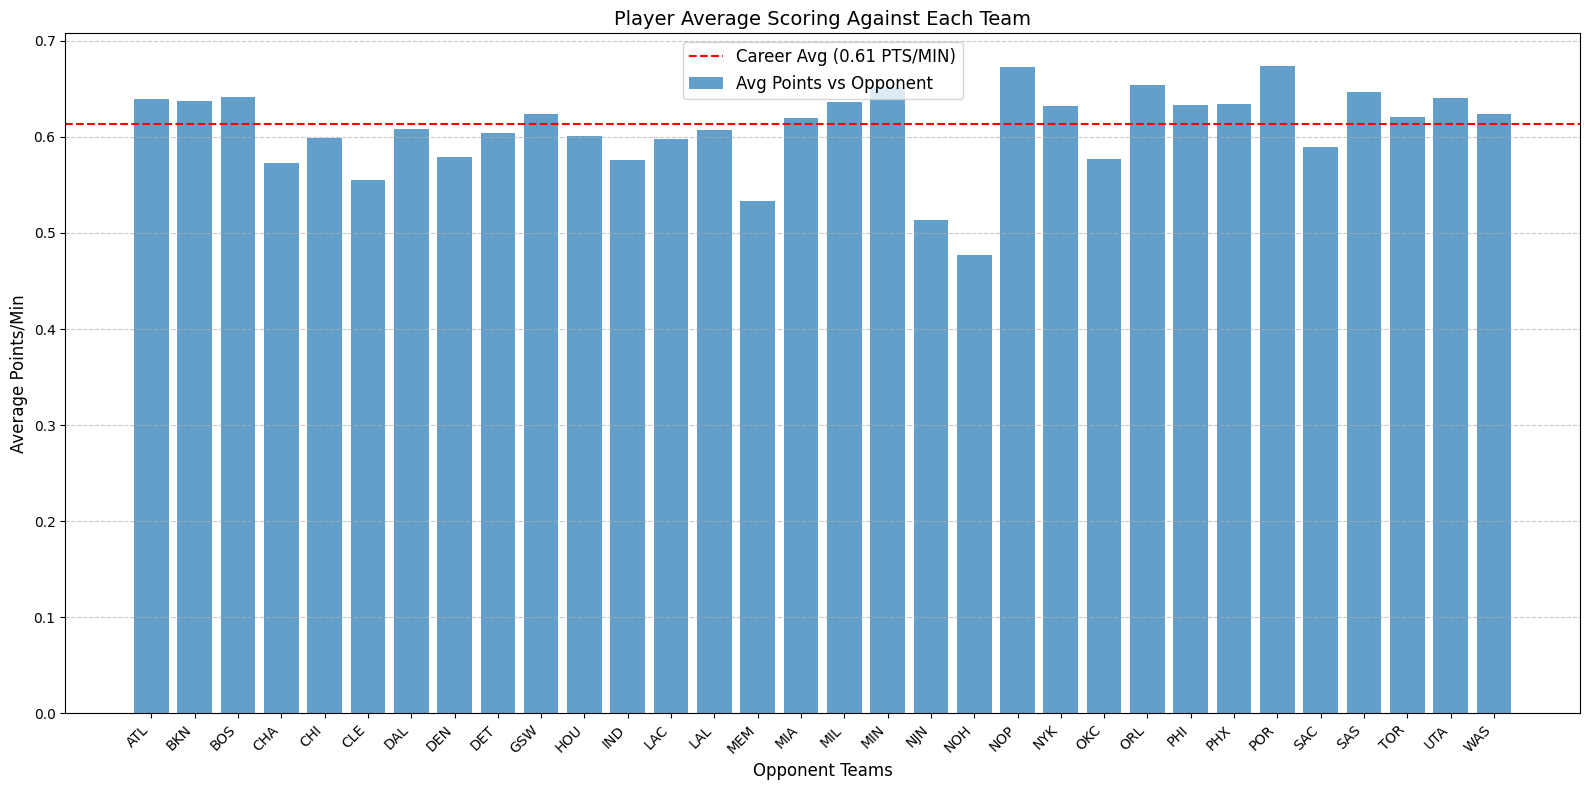

In [49]:
# Calculate career scoring per minute average
career_avg = player_stats["PTS"].mean()/player_stats["MIN"].mean()

# Calculate scoring averages against each opponent
team_avg = player_stats.groupby("Opponent")["PTS"].mean()/player_stats.groupby("Opponent")["MIN"].mean()

plt.figure(figsize=(16, 8))
bars = plt.bar(team_avg.index, team_avg.values, alpha=0.7, label='Avg Points vs Opponent')
plt.axhline(career_avg, color='red', linestyle='--', linewidth=1.5, label=f'Career Avg ({career_avg:.2f} PTS/MIN)')
plt.title("Player Average Scoring Against Each Team", fontsize=14)
plt.xlabel("Opponent Teams", fontsize=12)
plt.ylabel("Average Points/Min", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


/var/folders/6h/jfqddf4979v3__m65vbr8r2m0000gn/T/ipykernel_13525/3746139775.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spread_group_performance = merged_data.groupby("Spread_Group")["PTS"].mean()/merged_data.groupby("Spread_Group")["MIN"].mean()


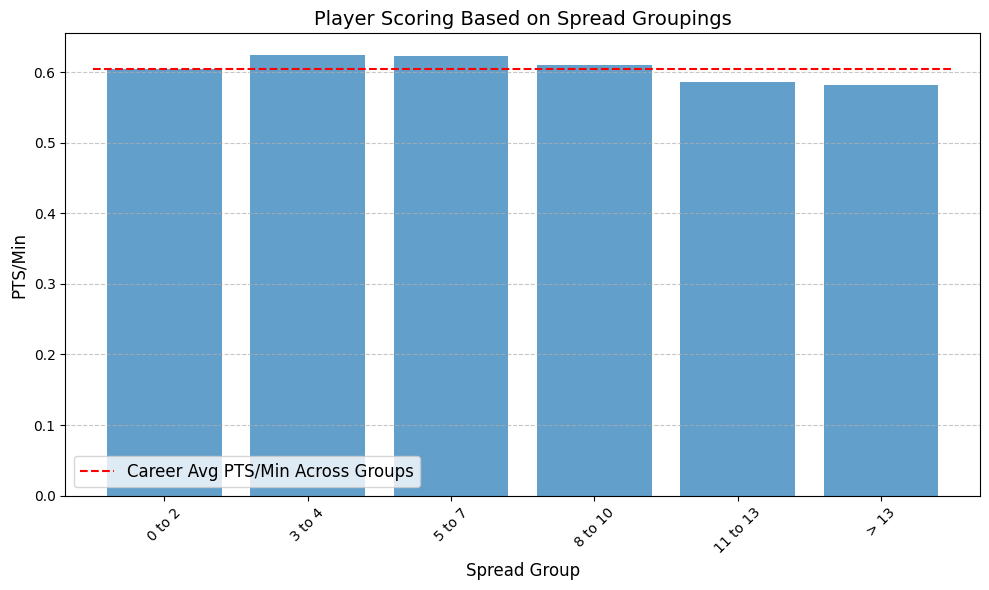

In [50]:
# Bin the spread values into groups
bins = [0, 2, 4, 7, 10, 13, float('inf')]
labels = ["0 to 2", "3 to 4", "5 to 7", "8 to 10", "11 to 13", "> 13"]
merged_data['Spread_Group'] = pd.cut(merged_data['spread'], bins=bins, labels=labels)

# Calculate average points scored for each spread group
spread_group_performance = merged_data.groupby("Spread_Group")["PTS"].mean()/merged_data.groupby("Spread_Group")["MIN"].mean()

plt.figure(figsize=(10, 6))
plt.hlines(
    y=spread_group_performance.mean(), 
    xmin=-0.5, 
    xmax=5.5, 
    color='red', 
    linestyle='--', 
    label='Career Avg PTS/Min Across Groups'
)
plt.bar(spread_group_performance.index, spread_group_performance.values, alpha=0.7)
plt.title("Player Scoring Based on Spread Groupings", fontsize=14)
plt.xlabel("Spread Group", fontsize=12)
plt.ylabel("PTS/Min", fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=12, loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


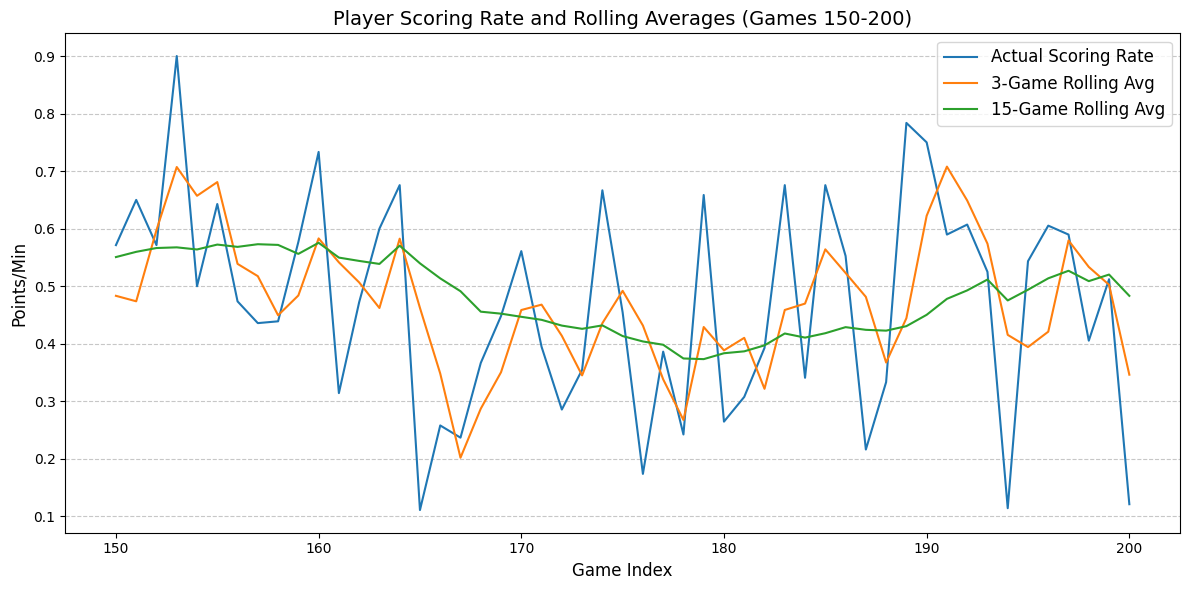

In [51]:
plt.figure(figsize=(12, 6))
subset = player_stats.loc[150:200]
plt.plot(subset['PTS_per_min'], label='Actual Scoring Rate')
plt.plot(subset['PTS_per_min_rolling_3'], label='3-Game Rolling Avg')
plt.plot(subset['PTS_per_min_rolling_15'], label='15-Game Rolling Avg')
plt.title("Player Scoring Rate and Rolling Averages (Games 150-200)", fontsize=14)
plt.xlabel("Game Index", fontsize=12)
plt.ylabel("Points/Min", fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 5. Model Training Setup
We'll choose a subset of features (contextual + rolling averages) and split our data into train/test sets.


In [52]:
# Drop rows with missing values in these key columns
combined_data = merged_data.dropna(subset=['PTS', 'MIN', 'spread'])

In [53]:
selected_features = [
    # Contextual Features
    'Home_Court_Advantage',
    'Interdivisional_Game',
    'Rest_Category_2-3 days',
    'Rest_Category_Less than 2 days',
    'Rest_Category_More than 3 days',
    'spread',
    
    # Recent Performance Metrics
    'FGM_per_min_rolling_3',
    'FG3M_per_min_rolling_3',
    'FTM_per_min_rolling_3',
    'REB_per_min_rolling_3',
    'AST_per_min_rolling_3',
    'STL_per_min_rolling_3',
    'BLK_per_min_rolling_3',
    'TOV_per_min_rolling_3',
    'PTS_per_min_rolling_3',

    # Mid-Term Performance Metrics
    'FGM_per_min_rolling_7',
    'FG3M_per_min_rolling_7',
    'FTM_per_min_rolling_7',
    'REB_per_min_rolling_7',
    'AST_per_min_rolling_7',
    'STL_per_min_rolling_7',
    'BLK_per_min_rolling_7',
    'TOV_per_min_rolling_7',
    'PTS_per_min_rolling_7',

    # Long-Term Performance Metrics
    'FGM_per_min_rolling_15',
    'FG3M_per_min_rolling_15',
    'FTM_per_min_rolling_15',
    'REB_per_min_rolling_15',
    'AST_per_min_rolling_15',
    'STL_per_min_rolling_15',
    'BLK_per_min_rolling_15',
    'TOV_per_min_rolling_15',
    'PTS_per_min_rolling_15',

    # Target
    'Target'
]

working_df = combined_data[selected_features].copy()

In [54]:
working_df2 = working_df.loc[:,~working_df.columns.duplicated()]
X, Y = working_df2.drop(columns="Target"), working_df["Target"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=23)


## 6. Train and Evaluate Baseline Models
Here we fit a variety of baseline models (without hyperparameter tuning) to compare MAPE.


I) Linear Regression 

In [55]:
# Train the model
lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)

# Predict and evaluate
lr_predictions = lr_model.predict(X_test)
lr_mape = mean_absolute_percentage_error(Y_test, lr_predictions)

II) Ridge Regression 

In [56]:
# Train the model
ridge_model = Ridge()
ridge_model.fit(X_train, Y_train)

# Predict and evaluate
ridge_predictions = ridge_model.predict(X_test)
ridge_mape = mean_absolute_percentage_error(Y_test, ridge_predictions)

III) Lasso Regression

In [57]:
# Train the model
lasso_model = Lasso()
lasso_model.fit(X_train, Y_train)

# Predict and evaluate
lasso_predictions = lasso_model.predict(X_test)
lasso_mape = mean_absolute_percentage_error(Y_test, lasso_predictions)

IV) Random Forest Model

In [58]:
# Train the model
rf_model = RandomForestRegressor(random_state=23)
rf_model.fit(X_train, Y_train)

# Predict and evaluate
rf_predictions = rf_model.predict(X_test)
rf_mape = mean_absolute_percentage_error(Y_test, rf_predictions)

V) XGBoost

In [59]:
# Train the model
xgb_model = XGBRegressor(random_state=23)
xgb_model.fit(X_train, Y_train)

# Predict and evaluate
xgb_predictions = xgb_model.predict(X_test)
xgb_mape = mean_absolute_percentage_error(Y_test, xgb_predictions)

VI) LightGBM

In [60]:
# Train the model
lgb_model = LGBMRegressor(random_state=23)
lgb_model.fit(X_train, Y_train)

# Predict and evaluate
lgb_predictions = lgb_model.predict(X_test)
lgb_mape = mean_absolute_percentage_error(Y_test, lgb_predictions)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000733 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6376
[LightGBM] [Info] Number of data points in the train set: 757, number of used features: 33
[LightGBM] [Info] Start training from score 21.468956
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

### Compare Baseline Model MAPE

In [61]:
comparison_df = pd.DataFrame({
    "Actual": Y_test,
    "Linear_Regression": lr_predictions,
    "Ridge": ridge_predictions,
    "Lasso": lasso_predictions,
    "Random_Forest": rf_predictions,
    "XGBoost": xgb_predictions,
    "LightGBM": lgb_predictions
})

# Calculate errors
comparison_df["Error_LR"] = abs(comparison_df["Actual"] - comparison_df["Linear_Regression"])
comparison_df["Error_Lasso"] = abs(comparison_df["Actual"] - comparison_df["Lasso"])
comparison_df["Error_Ridge"] = abs(comparison_df["Actual"] - comparison_df["Ridge"])
comparison_df["Error_RF"] = abs(comparison_df["Actual"] - comparison_df["Random_Forest"])
comparison_df["Error_XGB"] = abs(comparison_df["Actual"] - comparison_df["XGBoost"])
comparison_df["Error_LGB"] = abs(comparison_df["Actual"] - comparison_df["LightGBM"])

summary_df = pd.DataFrame({
    "Model": ["Linear Regression","Ridge","Lasso", "Random Forest", "XGBoost", "LightGBM"],
    "MAPE": [lr_mape,ridge_mape,lasso_mape, rf_mape, xgb_mape, lgb_mape]
}).sort_values(by="MAPE")

show(summary_df)
show(comparison_df)



## 7. Hyperparameter Tuning
We'll do a small GridSearch for Ridge (alpha values) and Random Forest (trees, depth, etc.) using 5-fold CV.

In [68]:
# Ridge Param Grid
param_grid_ridge = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    Ridge(),
    param_grid_ridge,
    scoring='neg_mean_absolute_percentage_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)
ridge_grid.fit(X_train, Y_train)

best_ridge_model = ridge_grid.best_estimator_
best_ridge_preds = best_ridge_model.predict(X_test)
best_ridge_mape = mean_absolute_percentage_error(Y_test, best_ridge_preds)

print("Best Params:", ridge_grid.best_params_)
print("Best CV Score (neg MAPE):", ridge_grid.best_score_)
print("Test MAPE:", best_ridge_mape)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Params: {'alpha': 0.1}
Best CV Score (neg MAPE): -0.3469347997914142
Test MAPE: 0.31335052498380145


In [70]:
# Random Forest Param Grid
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=23),
    param_grid_rf,
    scoring='neg_mean_absolute_percentage_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit Random Forest GridSearch on training data
rf_grid.fit(X_train, Y_train)

# Extract the best Random Forest model and evaluate
best_rf_model = rf_grid.best_estimator_
best_rf_preds = best_rf_model.predict(X_test)
best_rf_mape = mean_absolute_percentage_error(Y_test, best_rf_preds)

print("Best Random Forest Params:", rf_grid.best_params_)
print("Best Random Forest CV Score (neg MAPE):", rf_grid.best_score_)
print("Test MAPE (Random Forest):", best_rf_mape)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


In [65]:
### Coefficients and P-Values (Ridge Model)
# This helps interpret which features have the strongest relationships with the target.


f_values, p_values = f_regression(X_train, Y_train)
p_values = np.round(p_values, 5)
coef_summary = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient (Ridge)": ridge_model.coef_,
    "P-Value": p_values
}).sort_values(by="P-Value")
show(coef_summary)

## 8. Visualization of Predictions
 Below we plot actual vs predicted for a small subset of games and also the residuals.

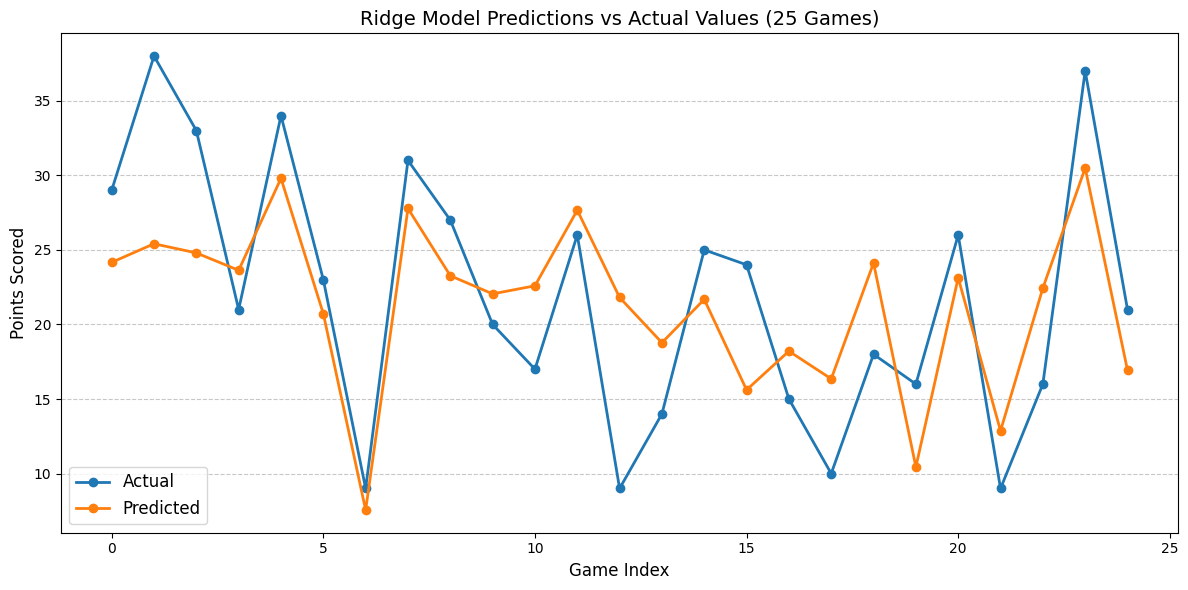

In [66]:
# Plot of Ridge Predictions vs Actual Values for 25 random games
plt.figure(figsize=(12, 6))
plt.plot(range(25), Y_test[:25], marker='o', label='Actual', linewidth=2)
plt.plot(range(25), ridge_predictions[:25], marker='o', label='Predicted', linewidth=2)
plt.title("Ridge Model Predictions vs Actual Values (25 Games)", fontsize=14)
plt.xlabel("Game Index", fontsize=12)
plt.ylabel("Points Scored", fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

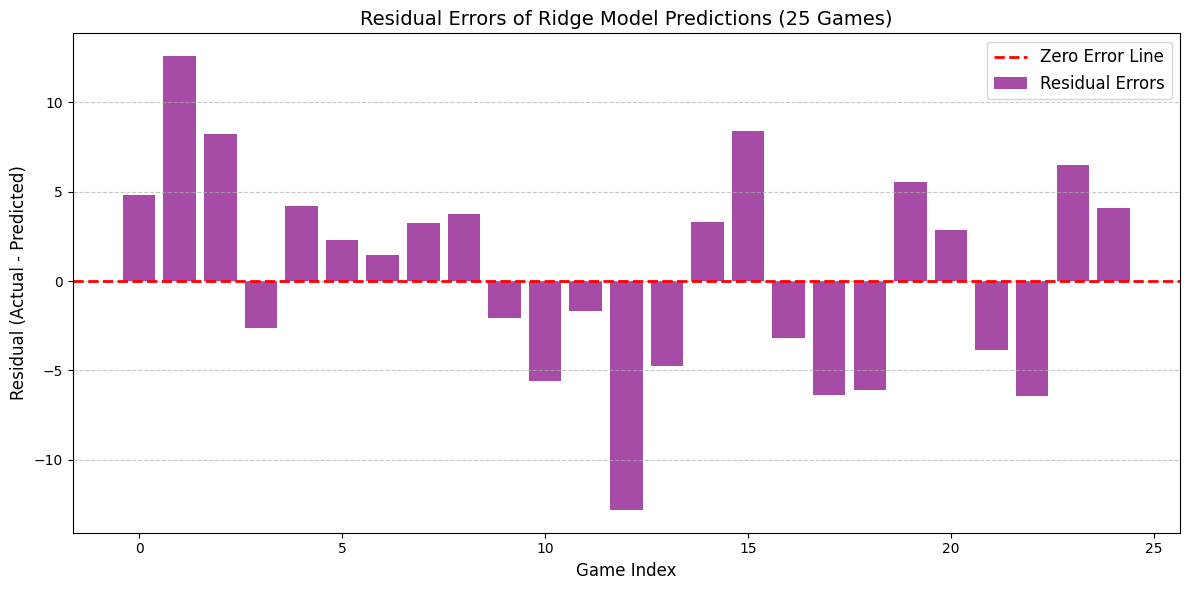

In [67]:
# Residuals of those same 25 predictions
residuals = Y_test[:25] - ridge_predictions[:25]
plt.figure(figsize=(12, 6))
plt.bar(range(25), residuals, color="purple", alpha=0.7, label="Residual Errors")
plt.title("Residual Errors of Ridge Model Predictions (25 Games)", fontsize=14)
plt.xlabel("Game Index", fontsize=12)
plt.ylabel("Residual (Actual - Predicted)", fontsize=12)
plt.axhline(0, color="red", linestyle="--", linewidth=2, label="Zero Error Line")
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Conclusion

1. **Baseline Performance**: Ridge or Random Forest often performs best out of the box, but further tuning can help.  
 2. **Hyperparameter Tuning**: The best alpha for Ridge was found via grid search; Random Forest also improved with the optimal combination of n_estimators, max_depth, etc.  
 3. **Interpretability**: Using `f_regression` or inspecting Ridge coefficients gives insight into which features matter most.  
 4. **Next Steps**:  
    - Add matchup-based variability (e.g., specific defender or team schemes).  
    - Integrate a "similar players" approach for more data.  
    - Possibly move toward a hierarchical model or neural network for further gains.

 **Thank you for reading!** 
 Check out the accompanying blog post for the narrative and additional context behind these numbers.